In [1]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
# import src.statsmodels as statsmodels 
import copy
import statsmodels.api as sm
from statsmodels.formula.api import ols


In [2]:
model = "word_task_v10_main_feature_gain_config"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 
print(h5.keys())
# for key in h5.keys():
    # print(key, h5[key].shape)
target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

In [3]:
### Get layer shape dict 

layer_shape_dict = pickle.load(open(analysis_dir / f"{model}_layer_shape_dict_time_avg.pkl", "rb"))
# batch got saved, drop batch dim in layer_shape_dict
layer_shape_dict = {k: v[1:] for k,v in layer_shape_dict.items() if 'gains' not in k}

In [4]:
unique_word_int = np.unique(h5['target_word_int'][:])

### For spatial tuning analysis, average over examples presented at same location, and compare across locations. 



95
12
Optimal number of bins: 15


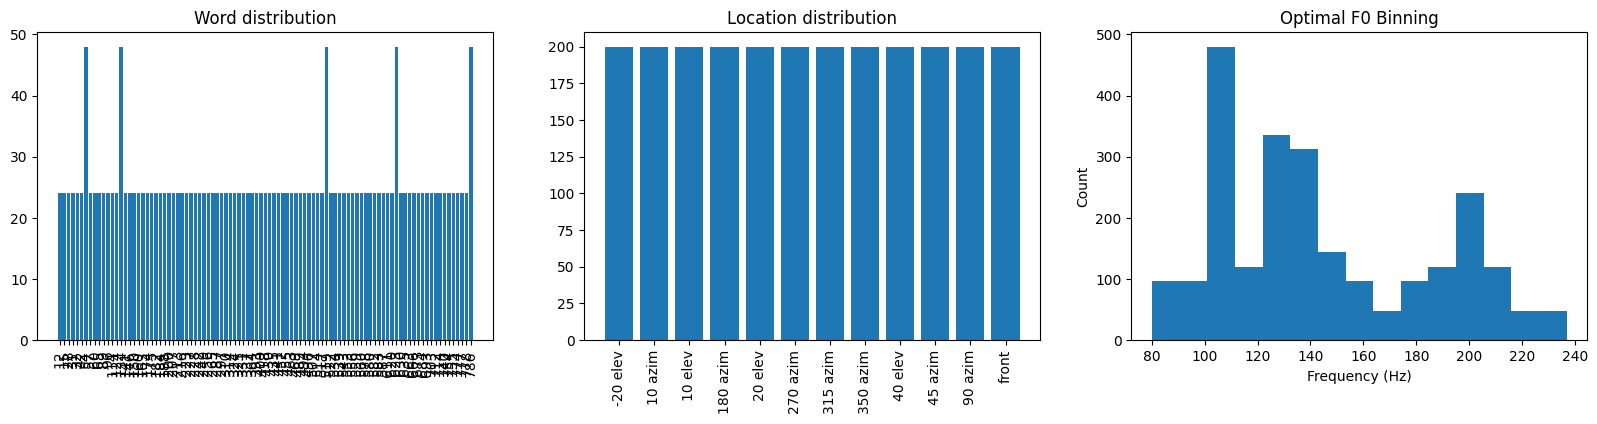

In [14]:
plt.figure(figsize=(20, 4))
plt.subplot(131)
words, count = np.unique(h5['target_word_int'][:], return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(132)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(locs))
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(133)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')
plt.show()




In [7]:
np.histogram(target_f0s, bins=optimal_bins)

(array([ 96,  96, 480, 120, 336, 312, 144,  96,  48,  96, 120, 240, 120,
         48,  48]),
 array([ 80.11249 ,  90.56528 , 101.01807 , 111.470856, 121.923645,
        132.37643 , 142.82922 , 153.28201 , 163.7348  , 174.18759 ,
        184.64038 , 195.09317 , 205.54594 , 215.99873 , 226.45152 ,
        236.90431 ], dtype=float32))

### Run and plot 2 way anova for each layer 

In [9]:
### init common labeling 

loc_list = np.zeros(len(target_locs), dtype=object)
for loc, loc_ixs in location_ixs.items():
    loc_list[loc_ixs] = loc

f0_list = [f"{bin} Hz" for bin in f0_bins]


## Demo anova on units from single layer 

In [10]:
layer_ix = 0
layer_name = f'hann_pool_{layer_ix}_cue'

## make pandas dataframe 
layer_acts = h5[layer_name][:]
n_units = layer_acts.shape[-1]
n_examples = layer_acts.shape[0]
dependent_var = layer_acts.flatten()
unit_ix = np.arange(layer_acts.shape[-1])
unit_ix = np.tile(unit_ix, n_examples)

act_df = pd.DataFrame(dependent_var, columns=['activation'])
act_df['unit_ix'] = unit_ix.astype(int)
act_df['f0'] = np.repeat(f0_list, n_units)
act_df['location'] = np.repeat(loc_list, n_units)
act_df['word_int'] = np.repeat(h5['target_word_int'][:], n_units).astype('int')



In [12]:
h5.keys()

<KeysViewHDF5 ['attn0_target', 'attn1_gains', 'attn1_target', 'attn2_gains', 'attn2_target', 'attn3_gains', 'attn3_target', 'attn4_gains', 'attn4_target', 'attn5_gains', 'attn5_target', 'attn6_gains', 'attn6_target', 'attncoch_gains', 'attnfc_gains', 'attnfc_target', 'cochleagram_cue', 'cochleagram_fg', 'conv_block_0_ln_cue', 'conv_block_0_ln_target', 'conv_block_0_relu_cue', 'conv_block_0_relu_target', 'conv_block_1_ln_cue', 'conv_block_1_ln_target', 'conv_block_1_relu_cue', 'conv_block_1_relu_target', 'conv_block_2_ln_cue', 'conv_block_2_ln_target', 'conv_block_2_relu_cue', 'conv_block_2_relu_target', 'conv_block_3_ln_cue', 'conv_block_3_ln_target', 'conv_block_3_relu_cue', 'conv_block_3_relu_target', 'conv_block_4_ln_cue', 'conv_block_4_ln_target', 'conv_block_4_relu_cue', 'conv_block_4_relu_target', 'conv_block_5_ln_cue', 'conv_block_5_ln_target', 'conv_block_5_relu_cue', 'conv_block_5_relu_target', 'conv_block_6_ln_cue', 'conv_block_6_ln_target', 'conv_block_6_relu_cue', 'conv_blo

In [ ]:
from joblib import Parallel, delayed
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm

# Define the formula
formula = 'activation ~ C(f0) + C(location) + C(word_int)' #  + C(f0):C(location) + C(f0):C(word_int) + C(location):C(word_int)'

# Initialize arrays
category_labels = ['f0', 'location', 'word',]# 'f0:location', 'f0:word', 'location:word']
n_cats = len(category_labels)
prop_var_per_unit = np.zeros((n_units, n_cats))
ssq_per_unit = np.zeros((n_units, n_cats))

# Function to process each unit
def process_unit(unit_i):
    model = ols(formula, act_df[act_df.unit_ix == unit_i]).fit()
    anova_table = sm.stats.anova_lm(model, typ=1)
    total_ss = anova_table.sum_sq.sum()
    ssq = anova_table['sum_sq'][:-1]
    prop_var = ssq / total_ss
    return unit_i, prop_var, ssq

# Parallel processing
results = Parallel(n_jobs=16)(delayed(process_unit)(unit_i) for unit_i in tqdm(range(n_units), total=n_units))

# Collect results
for unit_i, prop_var, ssq in results:
    prop_var_per_unit[unit_i] = prop_var
    ssq_per_unit[unit_i] = ssq

  0%|          | 0/640 [00:00<?, ?it/s]

100%|██████████| 640/640 [02:52<00:00,  3.72it/s]


In [13]:
anova_results_dict = {}
anova_results_dict[layer_name] = {'prop_var_per_unit': prop_var_per_unit, 'ssq_per_unit': ssq_per_unit}

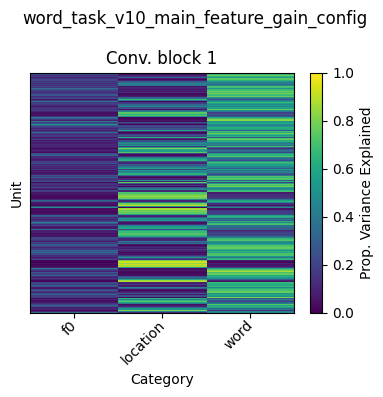

In [22]:
### Use imshow to plot the SSQ per unit
n_to_plot = len(anova_results_dict)
fig, ax = plt.subplots(1,n_to_plot, figsize=(4, 4))
ax = [ax]
REMOVE_ZERO_UNITS=False

n_cats = len(category_labels) # will be for location, f0, interaction
for layer_ix, (layer_name, results) in enumerate(anova_results_dict.items()):
    results_to_plot_ssq = results['prop_var_per_unit']
    if REMOVE_ZERO_UNITS:
        results_to_plot_ssq = results_to_plot_ssq[results_to_plot_ssq.sum(axis=1) > 0]
    n_units = results_to_plot_ssq.shape[0]
    panel = ax[layer_ix].imshow(results_to_plot_ssq, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='none')
    ax[layer_ix].set_xlabel('Category')
    ax[layer_ix].set_ylabel('Unit')
    ax[layer_ix].set_title(f"Conv. block {layer_ix+1}")
    ax[layer_ix].set_yticks([])
    ax[layer_ix].set_xticks(np.arange(n_cats))
    ax[layer_ix].set_xticklabels(category_labels, rotation=45, ha='right', va='center_baseline',  rotation_mode='anchor')
    # add colorbar
    cbar = plt.colorbar(panel, ax=ax[layer_ix])
    cbar.set_label('Prop. Variance Explained')

plt.suptitle(f"{model}")    
plt.tight_layout()

    # move legend outside of plot

(0.0, 1.0)

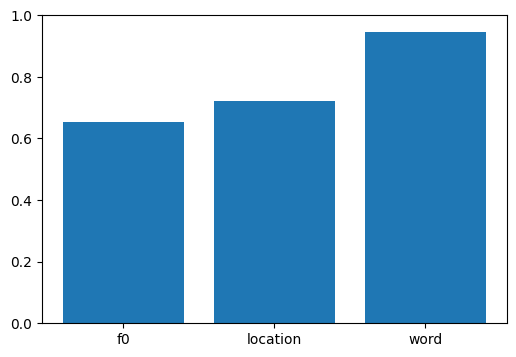

In [34]:
threshold = 0.1
p_f0, p_loc, p_word = (results['prop_var_per_unit'] > threshold).mean(0)
plt.figure(figsize=(6,4))
plt.bar(['f0', 'location', 'word'], [p_f0, p_loc, p_word])
plt.ylim(0,1)